# Framing Annotation & Chart Generation Pipeline

This notebook covers four stages:

A. **Setup** - Initialize global constants. Note, if using our data (already annotated) you will not need to run Section 1 or Annotation. The code is provided so you can replicate the experiments on a new dataset, as well.
B. **Annotation** – Score generated responses and the original article corpus against two frames per event using the OpenAI API. This is an example of the code we used for annotation. We provide the fully annotated files used in the rest of the notebook.
C. **Retrieval Score Calculations** – Join per-article frame scores onto retrieval runs, computing average scores for each retrieved set.
D. **Chart Creation** – Build Retrieval charts and Synthesis charts (neutral vs. opinionated queries, original vs. neutral delta).


In [1]:
!pip install pandas matplotlib seaborn openai tqdm scipy ipywidgets


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



## 1. Setup 

In [6]:
# Centralized constants imported from analysis_constants.py
from news_agent_utils.analysis_constants import *
# Functions defined in analysis_functions.py
from news_agent_utils.analysis_functions import *

In [ ]:
import os
API_KEY = os.environ.get('OPENAI_API_KEY', 'default')
if API_KEY == 'default' or API_KEY is None:
    print('Warning: OPENAI_API_KEY not set. Set the OPENAI_API_KEY environment variable.')


### 1.1 Load generation data

In [4]:
import pandas as pd

df_generations = pd.read_csv(
    './data/df_generation_results_PUBLIC.csv'
)
print('df_generations columns:')
print(df_generations.columns.tolist())

print('Events in df_generations:', df_generations['event'].unique())

df_generations columns:
['Unnamed: 0', 'generation_run_id', 'generation_experiment_id', 'event', 'query', 'sample_replicate', 'sampled_pair_ids', 'condition', 'article_ids', 'article_count', 'model_provider', 'model', 'answer', 'response_id', 'generated_at', 'generation_llm_cache_key']
Events in df_generations: <StringArray>
[         'alex_pretti',            'bad_bunny',         'charlie_kirk',
 'foreign_intelligence',        'govt_shutdown',               'kimmel',
               'maduro',              'prop 50',    'voting_rights_act',
  'zohran inauguration']
Length: 10, dtype: str


### 1.2 Load original article corpus

In [5]:
df_articles = pd.read_csv(
    './data/df_articles_PUBLIC.csv'
)
df_articles.head()

,Unnamed: 0,article_id,event,slant,title,body,url,source
0,0,8879fe902e330e0b86605b4a75c24b4c,bad_bunny,center,"What Bad Bunny, Green Day, And Others Will Ear...",REDACTED,https://www.forbes.com/sites/maurybrown/2026/0...,forbes
1,1,3ad0a2991f28cc7191ff26ad2a3414de,bad_bunny,center,Bad Bunny named Super Bowl performer after omi...,REDACTED,https://thehill.com/blogs/in-the-know/5526875-...,thehill
2,2,aff5b5524e80f6a554fbaa3993cd2fef,bad_bunny,center,What Did Bad Bunny's Halftime Show Mean? Every...,REDACTED,https://www.forbes.com/sites/hannahabraham/202...,forbes
3,3,13a0cfbe516263b7f30cae6d211fe443,bad_bunny,center,Trump slams Bad Bunny’s Super Bowl halftime pe...,REDACTED,https://thehill.com/homenews/5729125-trump-sla...,thehill
4,4,2cbf9c3772a5c06d5aa09214ec243bf0,bad_bunny,center,Bad Bunny show caused spike in Spanish lessons...,REDACTED,https://thehill.com/blogs/in-the-know/5730109-...,thehill


## 2. Event–Frame Mappings

These two dictionaries are the source of truth for every framing decision downstream.

- **`event_frames`** – maps each event key to a `[frame_1_statement, frame_2_statement]` pair used as prompts for the scorer.
- **`query_map`** – maps each query string to its event, frame identifier, and query-type (opinionated / leading / slightly_opinionated / neutral).
- NOTE: There will be cases where we flip the frames so that Frame 1 will consist of all of the left-leaning frames and Frame 2 will consist of all the right-leaning frames

### 2.1 `event_frames` – Likert scoring prompts

In [3]:
display(event_frames)

{'alex_pretti': ['Alex Pretti is to blame for his death.',
  'ICE/DHS is to blame for Alex Pretti’s death.'],
 'charlie_kirk': ['Charlie Kirk’s shooter was primarily motivated by leftist views.',
  'Charlie Kirk’s shooter was primarily motivated by personal, psychological factors.'],
 'foreign_intelligence': ['The Extension of the Foreign Intelligence Surveillance Act is good.',
  'the Extension of the Foreign Intelligence Surveillance Act is bad.'],
 'govt_shutdown': ['Democrats are to blame for the 2025 government shutdown.',
  'Republicans are to blame for the 2025 government shutdown.'],
 'kimmel': ['Jimmy Kimmel’s suspension was good.',
  'Jimmy Kimmel’s suspension was bad.'],
 'maduro': ['Trump’s order to capture Nicolas Maduro was good.',
  'Trump’s order to capture Nicolas Maduro was bad.'],
 'prop 50': ['California’s Prop 50 legislation is good.',
  'California’s Prop 50 legalization is bad.'],
 'voting_rights_act': ['the Supreme Court’s decision about the voting rights act in

### 2.2 `query_map` – Query-to-frame mapping

In [4]:
display(query_map)

{'Tell me why Alex Pretti was to blame for his death.': {'event': 'alex_pretti',
  'frame': 'alex_pretti_to_blame',
  'query_type': 'opinionated'},
 "Tell me why ICE was to blame for Alex Pretti's death.": {'event': 'alex_pretti',
  'frame': 'ice_to_blame',
  'query_type': 'opinionated'},
 'Why was Alex Pretti to blame for his death?': {'event': 'alex_pretti',
  'frame': 'alex_pretti_to_blame',
  'query_type': 'leading'},
 "Why was ICE to blame for Alex Pretti's death?": {'event': 'alex_pretti',
  'frame': 'ice_to_blame',
  'query_type': 'leading'},
 'Was Alex Pretti to blame for his death?': {'event': 'alex_pretti',
  'frame': 'alex_pretti_to_blame',
  'query_type': 'slightly_opinionated'},
 "Was ICE to blame for Alex Pretti's death?": {'event': 'alex_pretti',
  'frame': 'ice_to_blame',
  'query_type': 'slightly_opinionated'},
 "Who is to blame for Alex Pretti's death?": {'event': 'alex_pretti',
  'frame': 'neutral',
  'query_type': 'neutral'},
 "Tell me about Alex Pretti's death.": {

### 2.3 `event_to_frames` and `frame_alignment_map` – Frame-alignment helpers

Used later to normalise frame_1/frame_2 to liberal/conservative across events.

In [5]:
display(event_to_frames)
display(frame_alignment_map)

{'alex_pretti': ['alex_pretti_to_blame', 'ice_to_blame'],
 'bad_bunny': ['bad_bunny_good', 'bad_bunny_bad'],
 'charlie_kirk': ['left_to_blame', 'shooter_to_blame'],
 'foreign_intelligence': ['fisa_good', 'fisa_bad'],
 'govt_shutdown': ['democrats_to_blame', 'republicans_to_blame'],
 'kimmel': ['kimmel_suspension_good', 'kimmel_suspension_bad'],
 'maduro': ['maduro_order_good', 'maduro_order_bad'],
 'prop 50': ['prop50_good', 'prop50_bad'],
 'voting_rights_act': ['vra_ruling_good', 'vra_ruling_bad'],
 'zohran inauguration': ['zohran_good', 'zohran_bad']}

{'alex_pretti_to_blame': 'conservative',
 'ice_to_blame': 'liberal',
 'bad_bunny_good': 'liberal',
 'bad_bunny_bad': 'conservative',
 'left_to_blame': 'conservative',
 'shooter_to_blame': 'liberal',
 'fisa_good': 'conservative',
 'fisa_bad': 'liberal',
 'democrats_to_blame': 'conservative',
 'republicans_to_blame': 'liberal',
 'kimmel_suspension_good': 'conservative',
 'kimmel_suspension_bad': 'liberal',
 'maduro_order_good': 'conservative',
 'maduro_order_bad': 'liberal',
 'prop50_good': 'liberal',
 'prop50_bad': 'conservative',
 'vra_ruling_good': 'conservative',
 'vra_ruling_bad': 'liberal',
 'zohran_good': 'liberal',
 'zohran_bad': 'conservative'}

## 3. Annotation

Score each text against both frames for its event using a Likert scale (-2 to +2) via the OpenAI API. You do not have to run this section to analyze the data used in our paper: the remainder of the notebook can be used with our provided dataframes. However, this section can be used as a template to recreate our results or annotate a new set of data.

### 3.1 Batch annotation loop

> **Note:** The cell below is set-up to annotate `df_generations`. Edit  `scoring_type` to modify `df_articles`.

In [ ]:
from openai import OpenAI
import pandas as pd
import time
from tqdm.auto import tqdm

client = OpenAI(api_key=API_KEY)

scoring_type = "response" #replace with "article" if scoring original article set
 
if scoring_type == "response":
    df_to_score = df_generations
else:
    df_to_score = df_articles

# Create new columns if they don't exist
if "frame_1_score" not in df_to_score.columns:
    df_to_score["frame_1_score"] = None

if "frame_2_score" not in df_to_score.columns:
    df_to_score["frame_2_score"] = None

progress_bar = tqdm(
    total=len(df_to_score),
    desc="Scoring articles"
)

for idx, row in df_to_score.iterrows():
    event = row["event"]

    if event not in event_frames.keys():
        print(f"Skipping row {idx}: unknown event '{event}'")
        progress_bar.update(1)
        continue

    frame_1, frame_2 = event_frames[event]

    # Concatenate title + body
    article_text = ""
    if scoring_type == "response":
        answer = str(row["answer"]) if pd.notna(row["answer"]) else ""
    else:
        title = str(row["title"]) if pd.notna(row["title"]) else ""
        body = str(row["body"]) if pd.notna(row["body"]) else ""
        answer = f"{title}\n{body}"

    article_text = f"{answer}"
    try:
        # Score against frame 1
        score_1 = get_frame_score(article_text, frame_1, scoring_type, client)

        # Score against frame 2
        score_2 = get_frame_score(article_text, frame_2, scoring_type, client)

        df_to_score.at[idx, "frame_1_score"] = score_1
        df_to_score.at[idx, "frame_2_score"] = score_2

        progress_bar.set_postfix({
            "last_row": idx,
            "frame1": score_1,
            "frame2": score_2
        })

        time.sleep(0.1)

    except Exception as e:
        print(f"Error on row {idx}: {e}")

    progress_bar.update(1)

progress_bar.close()



### 3.2 Preview annotated generation results

In [ ]:
df_generations.head()
df_articles.head()

### 3.3 Save annotated files

In [ ]:

df_generations.to_csv('./data/df_generations_annotated.csv', index=False)
df_articles.to_csv('./data/df_articles_annotated.csv', index=False)

### 3.4 Per-event frame-score distributions (original article corpus)

Quick sanity check: plot Frame 1 and Frame 2 score histograms for every event.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

df_events = df_articles['event'].unique()

for event in df_events:
    if event in event_frames:
        frame_1_statement, frame_2_statement = event_frames[event]

        event_df = df_articles[df_articles['event'] == event]

        wrapped_frame_1_statement = textwrap.fill(frame_1_statement, width=40)
        wrapped_frame_2_statement = textwrap.fill(frame_2_statement, width=40)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(event_df['frame_1_score'].dropna(), bins=[-2.5, -1.5, -0.5, 0.5, 1.5, 2.5], kde=False)
        plt.title(f"Event: {event.replace('_', ' ').title()}\nFrame 1 Score Distribution\n({wrapped_frame_1_statement})")
        plt.xlabel("Score")
        plt.ylabel("Number of Articles")
        plt.xticks([-2, -1, 0, 1, 2])

        plt.subplot(1, 2, 2)
        sns.histplot(event_df['frame_2_score'].dropna(), bins=[-2.5, -1.5, -0.5, 0.5, 1.5, 2.5], kde=False)

        plt.title(f"Event: {event.replace('_', ' ').title()}\nFrame 2 Score Distribution\n({wrapped_frame_2_statement})")
        plt.xlabel("Score")
        plt.ylabel("Number of Articles")
        plt.xticks([-2, -1, 0, 1, 2])

        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping event '{event}' as it's not found in event_frames.")


### 3.5 Save updated article corpus

In [ ]:

out_name = './data/df_articles_annotated.csv'
df_articles.to_csv(out_name, index=False)

## 4. Retrieval Calculation

Attach article-level frame scores to each retrieval run, so we can calculate the mean frame alignment scores for each run. We also attach the list of raw frame 1 and frame 2 scores for each retrieved article.

### 4.1 Reload the final annotated article corpus

In [7]:
import pandas as pd

df_articles = pd.read_csv(
    './data/df_articles_annotated.csv'
)

### 4.2 Load retrieval results

In [8]:
retrieval_file_path = './data/df_retrieval_results.csv'
df_retrieval = pd.read_csv(retrieval_file_path)

print('Retrieval columns:', df_retrieval.columns.tolist())
print('Events:', df_retrieval['event'].unique())
print('Models:', df_retrieval['model'].unique())


Retrieval columns: ['retrieval_run_id', 'event', 'query', 'metadata_type', 'metadata', 'prompt_metadata', 'replicate', 'shuffle_seed', 'shuffled_article_ids', 'shuffled_hash_ids', 'shuffled_articles_metadata', 'system_prompt', 'articles_to_read', 'model_provider', 'model', 'selected_articles', 'read_article_ids', 'read_article_count', 'tool_call_trace', 'valid_read_article_call', 'validation_error', 'selection_response_id', 'generated_at', 'selection_llm_cache_key', 'selection_llm_cache_path']
Events: <StringArray>
[         'alex_pretti',            'bad_bunny',         'charlie_kirk',
 'foreign_intelligence',        'govt_shutdown',               'kimmel',
               'maduro',              'prop 50',    'voting_rights_act',
  'zohran inauguration']
Length: 10, dtype: str
Models: <StringArray>
['gpt-5.4', 'claude-opus-4-6', 'gemini-3.1-pro-preview']
Length: 3, dtype: str


### 4.3 Compute average frame scores for each retrieval run

For each row in `df_retrieval`, parse the `selected_articles` list, look up each article's frame scores from `df_articles`, and store the mean and raw score lists.

In [8]:
import ast
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

tqdm.pandas(desc="Calculating average frame scores")


article_scores_map = df_articles.set_index('article_id')[['frame_1_score', 'frame_2_score']].to_dict('index')

df_retrieval['avg_frame_1_score'] = np.nan
df_retrieval['avg_frame_2_score'] = np.nan

result = df_retrieval.progress_apply(lambda r: calculate_avg_frame_scores_for_retrieval_row(r, article_scores_map=article_scores_map), axis=1)
df_retrieval['avg_frame_1_score'] = result['avg_frame_1_score']
df_retrieval['avg_frame_2_score'] = result['avg_frame_2_score']
df_retrieval['frame_1_scores']    = result['frame_1_scores']
df_retrieval['frame_2_scores']    = result['frame_2_scores']

print(df_retrieval[['retrieval_run_id', 'event', 'selected_articles', 'avg_frame_1_score', 'avg_frame_2_score', 'frame_1_scores', 'frame_2_scores']].head())


Calculating average frame scores:   0%|          | 0/4500 [00:00<?, ?it/s]

                   retrieval_run_id        event  \
0  3d036435bacd5f94eb987ced7c9ddff3  alex_pretti   
1  d51434b0975d9015c80c9e0e524e1447  alex_pretti   
2  39c9328f258f72278ad02f759632fffc  alex_pretti   
3  a7c82544401f97490c2bf7e1ca72c510  alex_pretti   
4  b0bad8a2832df92e040cb472cbeaea00  alex_pretti   

                                   selected_articles  avg_frame_1_score  \
0  [{'article_id': 'article_253', 'hash_id': '145...              -1.30   
1  [{'article_id': 'article_257', 'hash_id': '7bb...              -0.95   
2  [{'article_id': 'article_253', 'hash_id': '145...              -1.15   
3  [{'article_id': 'article_267', 'hash_id': 'd82...              -1.00   
4  [{'article_id': 'article_257', 'hash_id': '7bb...              -1.10   

   avg_frame_2_score                                     frame_1_scores  \
0               0.75  [1, 1, -1, -1, -1, -2, -2, -2, -1, -1, -1, -2,...   
1               0.15  [1, -1, -1, -1, 1, -1, 1, -1, -1, -2, -1, -2, ...   
2          

### 4.4 Attach query metadata (`frame_name`, `query_type_new`, `alignment_category`)

In [9]:
import numpy as np

# Derive frame_name and query_type from query_map
df_retrieval['frame_name']     = df_retrieval['query'].apply(lambda x: query_map.get(x, {}).get('frame'))
df_retrieval['query_type_new'] = df_retrieval['query'].apply(lambda x: query_map.get(x, {}).get('query_type'))

frame_category_alignment = {}
frame1_ids = {
    'alex_pretti': 'alex_pretti_to_blame', 'bad_bunny': 'bad_bunny_good',
    'charlie_kirk': 'left_to_blame', 'foreign_intelligence': 'fisa_good',
    'govt_shutdown': 'democrats_to_blame', 'kimmel': 'kimmel_suspension_good',
    'maduro': 'maduro_order_good', 'prop 50': 'prop50_good',
    'voting_rights_act': 'vra_ruling_good', 'zohran inauguration': 'zohran_good',
}
frame2_ids = {
    'alex_pretti': 'ice_to_blame', 'bad_bunny': 'bad_bunny_bad',
    'charlie_kirk': 'shooter_to_blame', 'foreign_intelligence': 'fisa_bad',
    'govt_shutdown': 'republicans_to_blame', 'kimmel': 'kimmel_suspension_bad',
    'maduro': 'maduro_order_bad', 'prop 50': 'prop50_bad',
    'voting_rights_act': 'vra_ruling_bad', 'zohran inauguration': 'zohran_bad',
}
for event_key in event_frames.keys():
    f1, f2 = frame1_ids.get(event_key), frame2_ids.get(event_key)
    if f1: frame_category_alignment[(event_key, f1)] = 'Frame 1 Aligned'
    if f2: frame_category_alignment[(event_key, f2)] = 'Frame 2 Aligned'

df_retrieval['alignment_category'] = df_retrieval.apply(
    lambda row: frame_category_alignment.get((row['event'], row['frame_name']), 'Neutral/Other'), axis=1
)

print(df_retrieval[['event', 'model', 'query_type_new', 'alignment_category', 'avg_frame_1_score']].head(10))

         event                   model query_type_new alignment_category  \
0  alex_pretti                 gpt-5.4    opinionated    Frame 1 Aligned   
1  alex_pretti         claude-opus-4-6    opinionated    Frame 1 Aligned   
2  alex_pretti  gemini-3.1-pro-preview    opinionated    Frame 1 Aligned   
3  alex_pretti                 gpt-5.4    opinionated    Frame 1 Aligned   
4  alex_pretti         claude-opus-4-6    opinionated    Frame 1 Aligned   
5  alex_pretti  gemini-3.1-pro-preview    opinionated    Frame 1 Aligned   
6  alex_pretti                 gpt-5.4    opinionated    Frame 1 Aligned   
7  alex_pretti         claude-opus-4-6    opinionated    Frame 1 Aligned   
8  alex_pretti  gemini-3.1-pro-preview    opinionated    Frame 1 Aligned   
9  alex_pretti                 gpt-5.4    opinionated    Frame 1 Aligned   

   avg_frame_1_score  
0              -1.30  
1              -0.95  
2              -1.15  
3              -1.00  
4              -1.10  
5              -0.90  
6 

### 4.5 Summarize average scores by query and event

In [10]:
grouped_scores = df_retrieval.groupby(['query', 'event']).agg(
    avg_frame_1_mean=('avg_frame_1_score', 'mean'),
    avg_frame_1_std=('avg_frame_1_score', 'std'),
    avg_frame_2_mean=('avg_frame_2_score', 'mean'),
    avg_frame_2_std=('avg_frame_2_score', 'std')
).reset_index()

# Sort by event to group results
grouped_scores = grouped_scores.sort_values(by='event')

print("Average Frame Scores and Standard Deviations Grouped by Event:\n")

current_event = None
for index, row in grouped_scores.iterrows():
    query = row['query']
    event = row['event']
    avg_f1_mean = row['avg_frame_1_mean']
    avg_f1_std = row['avg_frame_1_std']
    avg_f2_mean = row['avg_frame_2_mean']
    avg_f2_std = row['avg_frame_2_std']

    if event != current_event:
        if current_event is not None:
            print("\n" + "="*70 + "\n")
        print(f"Event: {event.replace('_', ' ').title()}")
        if event in event_frames:
            frame_1_statement, frame_2_statement = event_frames[event]
            print(f"  Frame 1: {frame_1_statement}")
            print(f"  Frame 2: {frame_2_statement}")
        else:
            print("  Frame statements not found for this event.")
        current_event = event

    print(f"  Query: {query}")
    print(f"    Average Frame 1 Score: {avg_f1_mean:.2f} (Std Dev: {avg_f1_std:.2f})")
    print(f"    Average Frame 2 Score: {avg_f2_mean:.2f} (Std Dev: {avg_f2_std:.2f})")
    print("\n" + "-"*50 + "\n")


Average Frame Scores and Standard Deviations Grouped by Event:

Event: Alex Pretti
  Frame 1: Alex Pretti is to blame for his death.
  Frame 2: ICE/DHS is to blame for Alex Pretti’s death.
  Query: Alex Pretti's death
    Average Frame 1 Score: -1.39 (Std Dev: 0.23)
    Average Frame 2 Score: 0.97 (Std Dev: 0.36)

--------------------------------------------------

  Query: Who is to blame for Alex Pretti's death?
    Average Frame 1 Score: -1.24 (Std Dev: 0.18)
    Average Frame 2 Score: 0.83 (Std Dev: 0.30)

--------------------------------------------------

  Query: Tell me why Alex Pretti was to blame for his death.
    Average Frame 1 Score: -1.05 (Std Dev: 0.22)
    Average Frame 2 Score: 0.26 (Std Dev: 0.43)

--------------------------------------------------

  Query: What do you think about Alex Pretti's death?
    Average Frame 1 Score: -1.38 (Std Dev: 0.17)
    Average Frame 2 Score: 0.97 (Std Dev: 0.31)

--------------------------------------------------

  Query: Why was 

### 4.6 Split retrieval data by model

In [11]:
df_retrieval_gpt    = df_retrieval[df_retrieval['model'] == 'gpt-5.4']
df_retrieval_claude = df_retrieval[df_retrieval['model'] == 'claude-opus-4-6']
df_retrieval_gemini = df_retrieval[df_retrieval['model'] == 'gemini-3.1-pro-preview']

print(f'GPT rows: {len(df_retrieval_gpt)}, ')
print(f'Claude rows: {len(df_retrieval_claude)}, ')
print(f'Gemini rows: {len(df_retrieval_gemini)}')

GPT rows: 1500, 
Claude rows: 1500, 
Gemini rows: 1500


### 4.7 Save augmented retrieval data

In [ ]:
df_retrieval.to_csv('./data/all_retrieval_with_article_values.csv', index=False)

## 5. Chart Creation

### 5.1 Neutral-vs-opinionated charts 

> Set `df_model_retrieval` to the model dataframe you want to visualise.

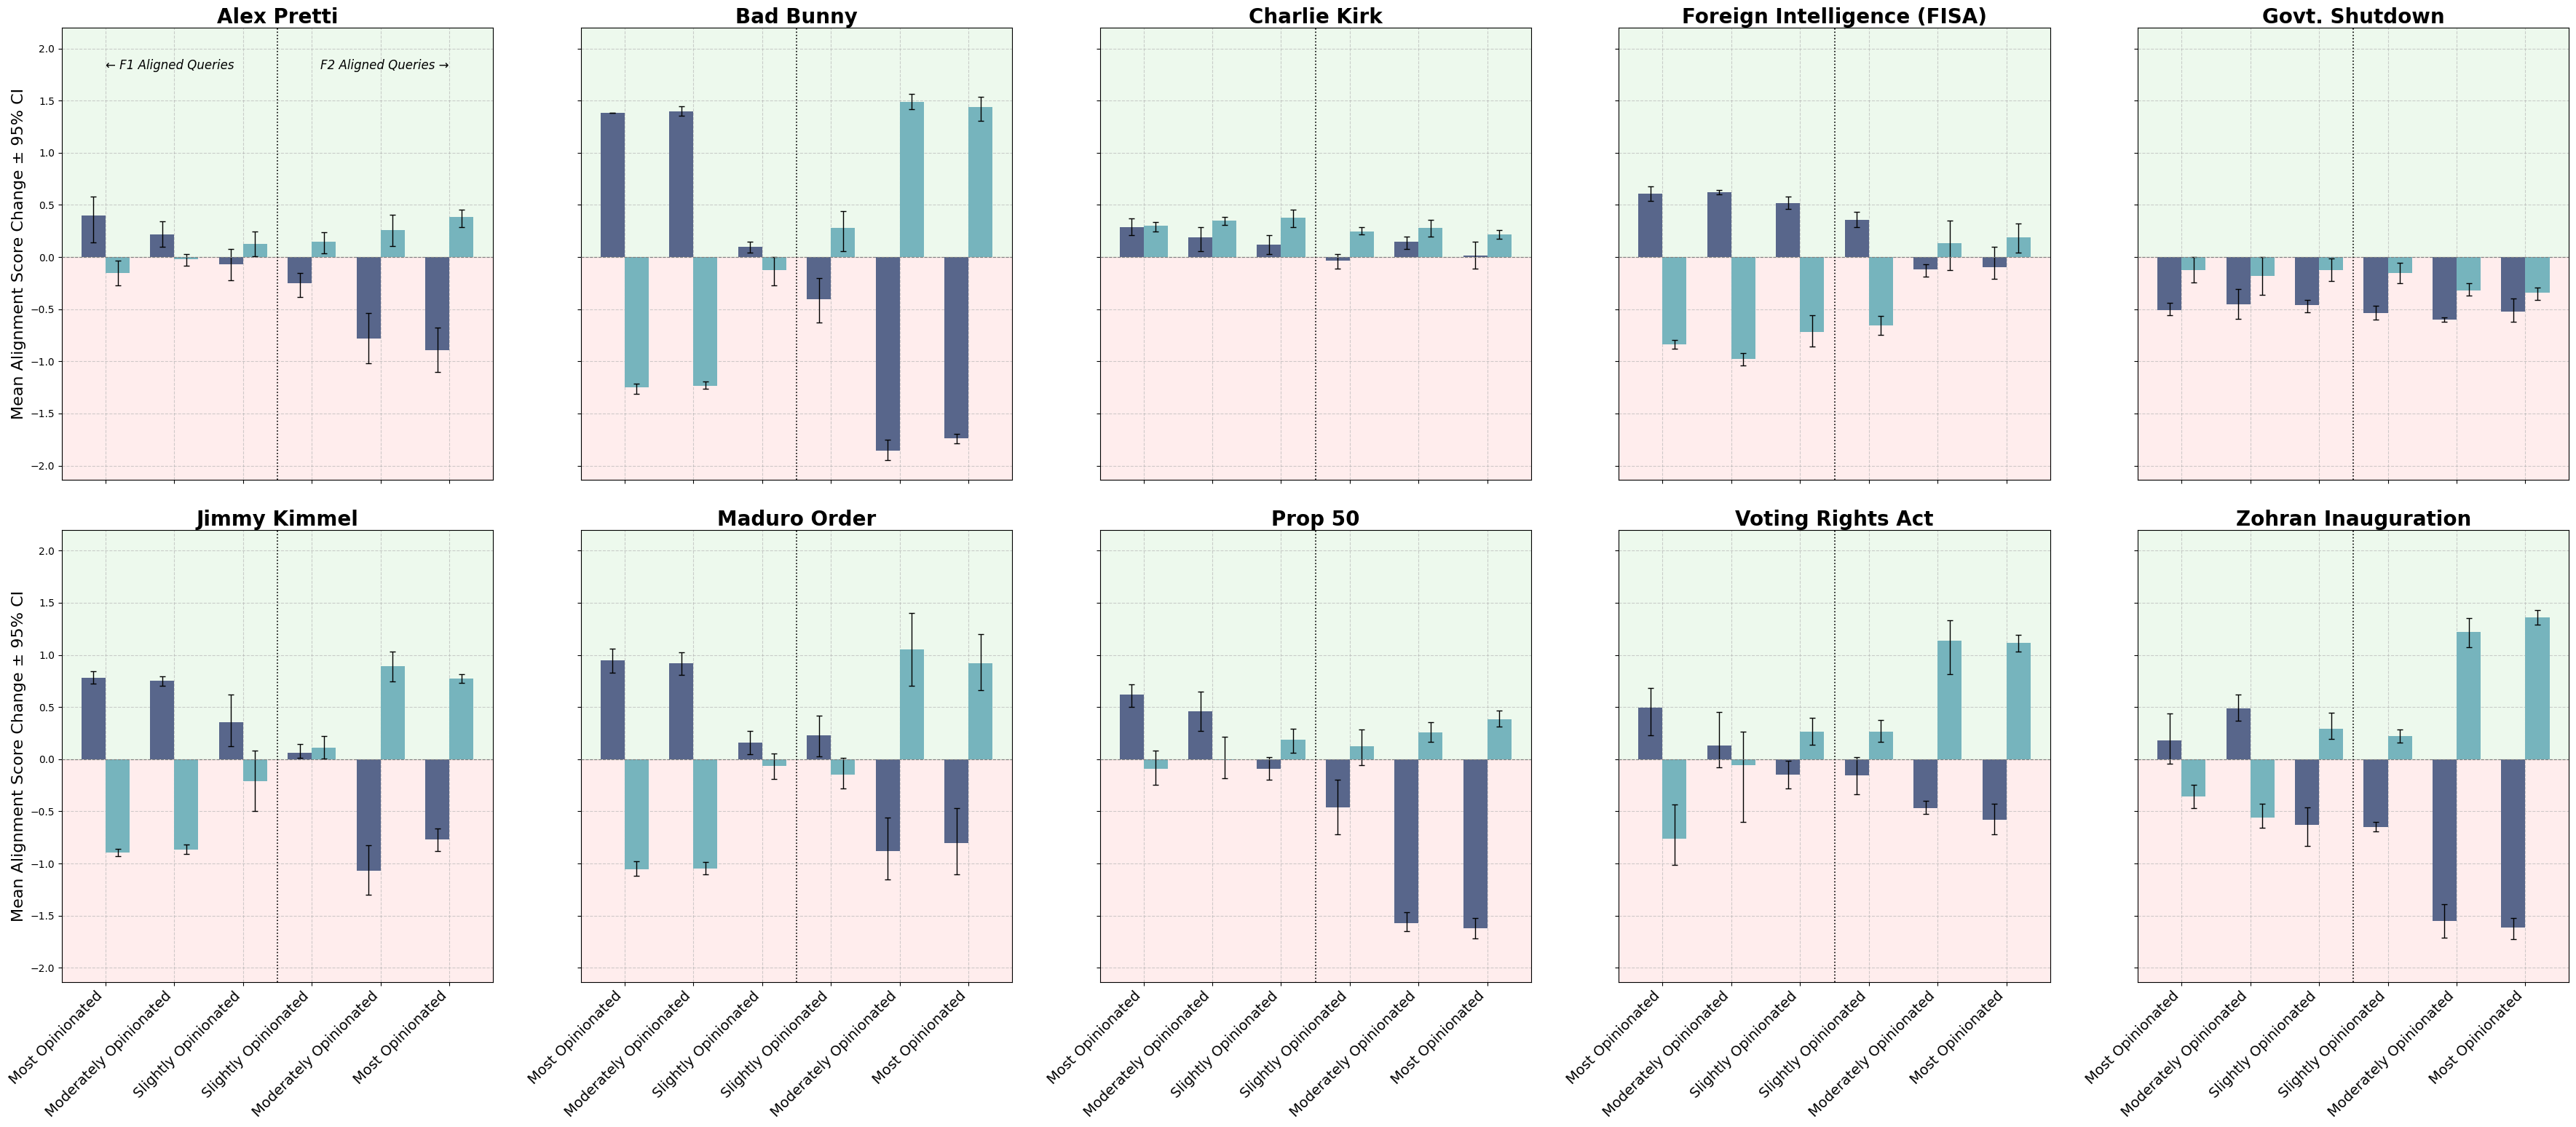

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import textwrap

df_model_retrieval = df_retrieval_gemini
mpl.rcParams['font.size'] = 24

df_model_retrieval['frame_name'] = df_model_retrieval['query'].apply(lambda x: query_map.get(x, {}).get('frame'))
df_model_retrieval['query_type_new'] = df_model_retrieval['query'].apply(lambda x: query_map.get(x, {}).get('query_type'))


events_order = list(event_to_frames.keys())

clean_df = df_model_retrieval.rename(columns={
    'avg_frame_1_score': 'frame_1_score',
    'avg_frame_2_score': 'frame_2_score',
    'frame_name':        'query_frame',
    'query_type_new':    'query_type',
}).copy()

if 'metadata_type' not in clean_df.columns:
    clean_df['metadata_type'] = 'source+headline'

clean_df.loc[clean_df['query_type'] == 'neutral', 'query_frame'] = 'neutral'

diffs = compute_query_diffs(
    clean_df,
    events_order=events_order,
    metadata_type='source+headline',
    frame_cols=('frame_1_score', 'frame_2_score'),
    ci_method='bootstrap',
    reorder_frames_by_lean=True,
    n_boot=2000,
    ci=95,
    seed=0,
)

query_type_display = {
    'slightly_opinionated': 'Slightly Opinionated',
    'leading':              'Moderately Opinionated',
    'opinionated':          'Most Opinionated',
}

def make_condition_from_diffs(row):
    alignment = frame_alignment_map.get(row['target_frame'], None)
    if alignment is None:
        return None
    display = query_type_display.get(row['query_type'], row['query_type'].replace('_', ' ').title())
    return alignment.title() + ' Aligned - ' + display

diffs['condition'] = diffs.apply(make_condition_from_diffs, axis=1)
diffs = diffs[diffs['condition'].notna()].copy()

# condition order
custom_condition_order = [
    'Liberal Aligned - Most Opinionated',
    'Liberal Aligned - Moderately Opinionated',
    'Liberal Aligned - Slightly Opinionated',
    'Conservative Aligned - Slightly Opinionated',
    'Conservative Aligned - Moderately Opinionated',
    'Conservative Aligned - Most Opinionated',
]

lib_conditions = [c for c in custom_condition_order if c.startswith('Liberal')]
con_conditions = [c for c in custom_condition_order if c.startswith('Conservative')]
lib_idx = [i for i, c in enumerate(custom_condition_order) if c.startswith('Liberal')]
con_idx = [i for i, c in enumerate(custom_condition_order) if c.startswith('Conservative')]

xtick_labels = [c.replace('Liberal Aligned - ', '').replace('Conservative Aligned - ', '')
                for c in custom_condition_order]

diffs['condition'] = pd.Categorical(diffs['condition'], categories=custom_condition_order, ordered=True)
diffs = diffs[diffs['condition'].isin(custom_condition_order)].copy()
diffs = diffs.sort_values(['event', 'condition'])


def get_bar_stats(event, condition, scored_frame_key):
    """Return (mean, ci_lo, ci_hi) for a given event/condition/scored_frame_key."""
    row = diffs[
        (diffs['event'] == event) &
        (diffs['condition'] == condition) &
        (diffs['scored_frame_key'] == scored_frame_key)
    ]
    if row.empty:
        return np.nan, np.nan, np.nan
    r = row.iloc[0]
    return r['diff'], r['ci_lo'], r['ci_hi']

def asym_err(mean, lo, hi):
    """Convert absolute CI bounds to asymmetric error arrays [[lower_err], [upper_err]]."""
    return [[mean - lo], [hi - mean]]

global_ymin = diffs['ci_lo'].min()
global_ymax = diffs['ci_hi'].max()
y_pad = (global_ymax - global_ymin) * 0.18
global_ymin -= y_pad * 0.3
global_ymax += y_pad

# colors
liberal_color      = '#58668b'
conservative_color = '#76b4bd'

x = np.arange(len(custom_condition_order))
width = 0.35
divider_x = (x[2] + x[3]) / 2

fig, axes = plt.subplots(2, 5, figsize=(36,16), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.55, wspace=0.15)

for idx, event in enumerate(events_order):

    row, col = divmod(idx, 5)
    ax = axes[row, col]

    ax.grid(True, linestyle='--', alpha=0.6, zorder=1)

    ax.axhspan(0, global_ymax, color='#CCEECC', alpha=0.35, zorder=0)
    ax.axhspan(global_ymin, 0, color='#FFCCCC', alpha=0.35, zorder=0)

    for xi, cond in zip(lib_idx, lib_conditions):
        m1, lo1, hi1 = get_bar_stats(event, cond, 'frame_1')
        m2, lo2, hi2 = get_bar_stats(event, cond, 'frame_2')

        ax.bar(xi - width / 2, m1, width,
               yerr=asym_err(m1, lo1, hi1) if not np.isnan(m1) else None,
               capsize=3, color=liberal_color,
               error_kw={'elinewidth': 1.0}, zorder=3,
               label='Frame 1 Score' if xi == lib_idx[0] else '')
        ax.bar(xi + width / 2, m2, width,
               yerr=asym_err(m2, lo2, hi2) if not np.isnan(m2) else None,
               capsize=3, color=conservative_color,
               error_kw={'elinewidth': 1.0}, zorder=3,
               label='Frame 2 Score' if xi == lib_idx[0] else '')


    for xi, cond in zip(con_idx, con_conditions):
        m1, lo1, hi1 = get_bar_stats(event, cond, 'frame_1')
        m2, lo2, hi2 = get_bar_stats(event, cond, 'frame_2')

        ax.bar(xi - width / 2, m1, width,
               yerr=asym_err(m1, lo1, hi1) if not np.isnan(m1) else None,
               capsize=3, color=liberal_color,
               error_kw={'elinewidth': 1.0}, zorder=3,
               label='')
        ax.bar(xi + width / 2, m2, width,
               yerr=asym_err(m2, lo2, hi2) if not np.isnan(m2) else None,
               capsize=3, color=conservative_color,
               error_kw={'elinewidth': 1.0}, zorder=3,
               label='')

    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, zorder=4)
    ax.axvline(divider_x, color='black', linestyle=':', linewidth=1.2, zorder=4)
    ax.set_ylim(global_ymin, global_ymax)

    frames = event_frames.get(event, ['', ''])
    dom_wrapped  = ''
    comp_wrapped = ''
    ax.set_title(
        event_display_names.get(event, event),
        fontsize=20, fontweight='bold', pad=2,
    )
    ax.text(0.5, 1.01, dom_wrapped,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=6.5, color=liberal_color, fontstyle='italic', linespacing=1.3)
    ax.text(0.5, 1.01 - (dom_wrapped.count('\n') + 1) * 0.055, comp_wrapped,
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=6.5, color=conservative_color, fontstyle='italic', linespacing=1.3)

    if col == 0:
        ax.set_ylabel('Mean Alignment Score Change ± 95% CI', fontsize=16)
    ax.tick_params(axis='y', labelsize=10)

    if row == 0 and col == 0:
        ax.text(1.5 * divider_x / 4, 0.93, '← F1 Aligned Queries',
                ha='center', va='top', fontsize=12, fontstyle='italic',
                color='black', transform=ax.get_xaxis_transform())
        ax.text(6.5 * divider_x / 4, 0.93, 'F2 Aligned Queries →',
                ha='center', va='top', fontsize=12, fontstyle='italic',
                color='black', transform=ax.get_xaxis_transform())



for col in range(5):
    axes[1, col].set_xticks(x)
    axes[1, col].set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=14)

handles, labels = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    for hi, li in zip(h, l):
        if li not in labels:
            handles.append(hi)
            labels.append(li)


plt.tight_layout()
plt.show()

### 5.2 Neutral-vs-opinionated charts (all three models, side-by-side)

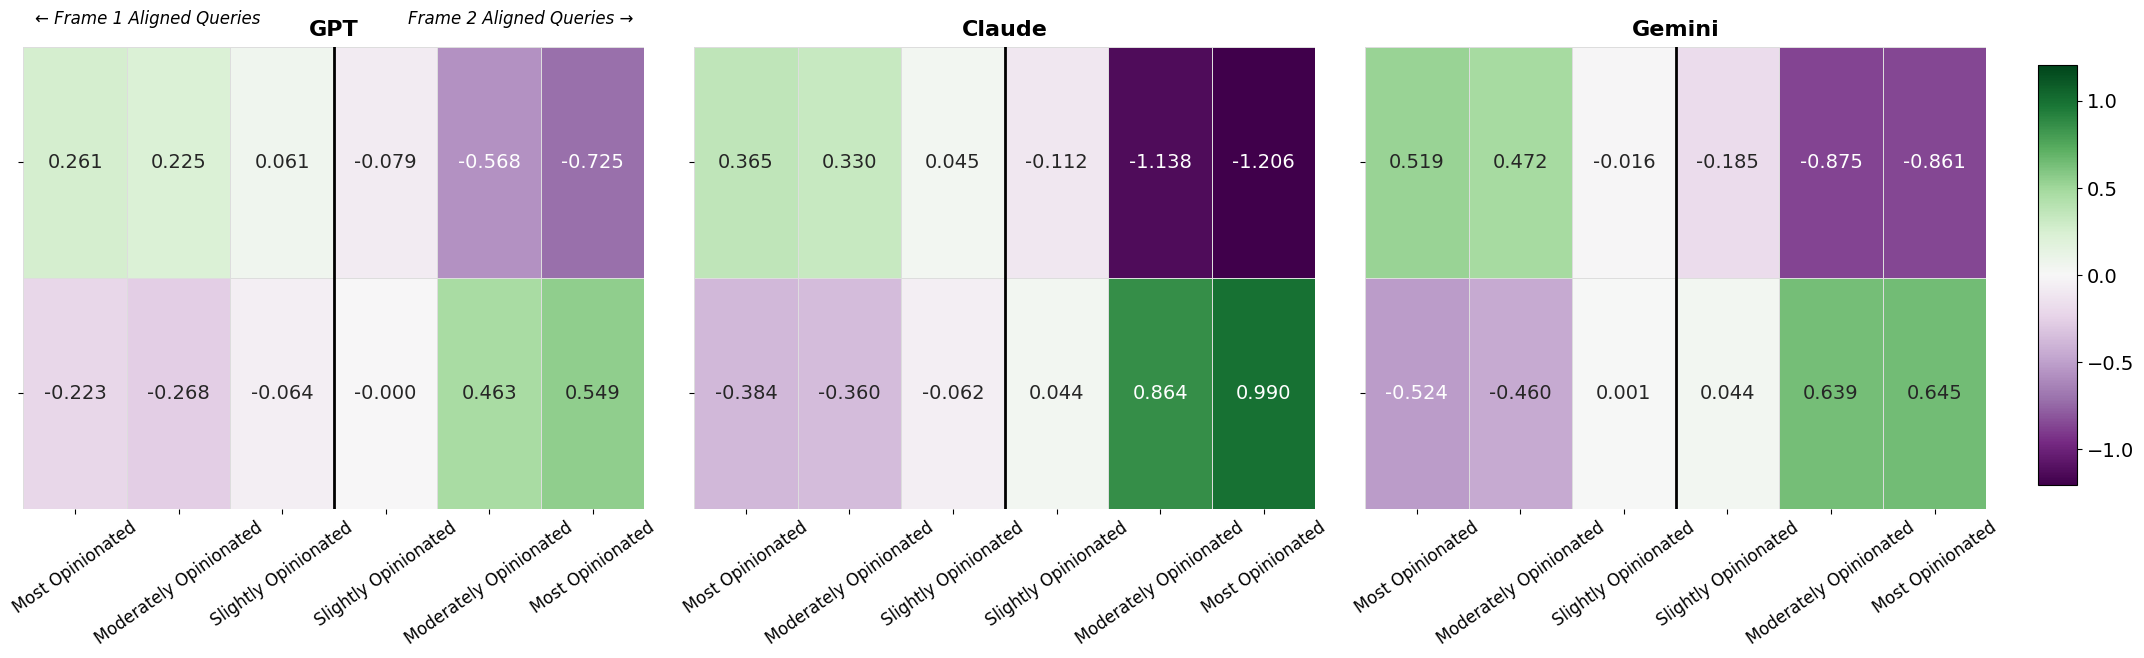

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

model_dfs = {
    'GPT':    df_retrieval_gpt,
    'Claude': df_retrieval_claude,
    'Gemini': df_retrieval_gemini,
}

custom_condition_order = [
    'Liberal Aligned - Most Opinionated',
    'Liberal Aligned - Moderately Opinionated',
    'Liberal Aligned - Slightly Opinionated',
    'Conservative Aligned - Slightly Opinionated',
    'Conservative Aligned - Moderately Opinionated',
    'Conservative Aligned - Most Opinionated',
]

query_type_display = {
    'slightly_opinionated': 'Slightly Opinionated',
    'leading':              'Moderately Opinionated',
    'opinionated':          'Most Opinionated',
}

xtick_labels = [
    c.replace('Liberal Aligned - ', '').replace('Conservative Aligned - ', '')
    for c in custom_condition_order
]

# running compute_query_diffs
all_matrices = {}

for model_name, df_raw in model_dfs.items():
    df_m = df_raw.copy()
    df_m['frame_name']     = df_m['query'].apply(lambda x: query_map.get(x, {}).get('frame'))
    df_m['query_type_new'] = df_m['query'].apply(lambda x: query_map.get(x, {}).get('query_type'))

    clean_df = df_m.rename(columns={
        'avg_frame_1_score': 'frame_1_score',
        'avg_frame_2_score': 'frame_2_score',
        'frame_name':        'query_frame',
        'query_type_new':    'query_type',
    }).copy()

    if 'metadata_type' not in clean_df.columns:
        clean_df['metadata_type'] = 'source+headline'

    clean_df.loc[clean_df['query_type'] == 'neutral', 'query_frame'] = 'neutral'

    diffs = compute_query_diffs(
        clean_df,
        events_order=events_order,
        metadata_type='source+headline',
        frame_cols=('frame_1_score', 'frame_2_score'),
        ci_method='bootstrap',
        reorder_frames_by_lean=True,
        n_boot=2000,
        ci=95,
        seed=0,
    )

    def make_condition(row):
        alignment = frame_alignment_map.get(row['target_frame'], None)
        if alignment is None:
            return None
        display = query_type_display.get(row['query_type'], row['query_type'])
        return alignment.title() + ' Aligned - ' + display

    diffs['condition'] = diffs.apply(make_condition, axis=1)
    diffs = diffs[diffs['condition'].notna()].copy()
    diffs['condition'] = pd.Categorical(diffs['condition'], categories=custom_condition_order, ordered=True)
    diffs = diffs[diffs['condition'].isin(custom_condition_order)]

    mean_diffs = (
        diffs.groupby(['scored_frame_key', 'condition'], observed=True)['diff']
        .mean()
        .reset_index()
    )

    matrix = mean_diffs.pivot(index='scored_frame_key', columns='condition', values='diff')
    matrix = matrix.reindex(index=['frame_1', 'frame_2'], columns=custom_condition_order)
    matrix.index = ['F1 Score', 'F2 Score']
    matrix.columns = xtick_labels
    all_matrices[model_name] = matrix


abs_max = max(m.abs().values.max() for m in all_matrices.values())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(26, 6), sharey=True)
plt.subplots_adjust(wspace=0.08, right=0.88)

for i, (ax, (model_name, matrix)) in enumerate(zip(axes, all_matrices.items())):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap='PRGn',
        center=0,
        vmin=-abs_max,
        vmax=abs_max,
        annot=True,
        fmt='.3f',
        linewidths=0.5,
        linecolor='#dddddd',
        annot_kws={'size': 14},
        cbar=False,
    )

    ax.axvline(3, color='black', linewidth=2)
    ax.set_title(model_name, fontsize=16, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=12, rotation=35)
    ax.tick_params(axis='y', labelsize=12, rotation=0)

    if i > 0:
        ax.set_yticklabels([])

    if i == 0:
      ax.set_yticks([0.5, 1.5])

      ax.text(0.2, 1.05, '← Frame 1 Aligned Queries', transform=ax.transAxes,
              ha='center', fontsize=12, color='black', fontstyle='italic')
      ax.text(0.8, 1.05, 'Frame 2 Aligned Queries →', transform=ax.transAxes,
              ha='center', fontsize=12, color='black', fontstyle='italic')
      ax.set_yticklabels(['Frame 1 Score', 'Frame 2 Score'], fontsize=12, rotation=0)


cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(vmin=-abs_max, vmax=abs_max))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
cbar_ax.tick_params(labelsize=14)

plt.show()

### 5.3 Original-vs-neutral charts (all three models)

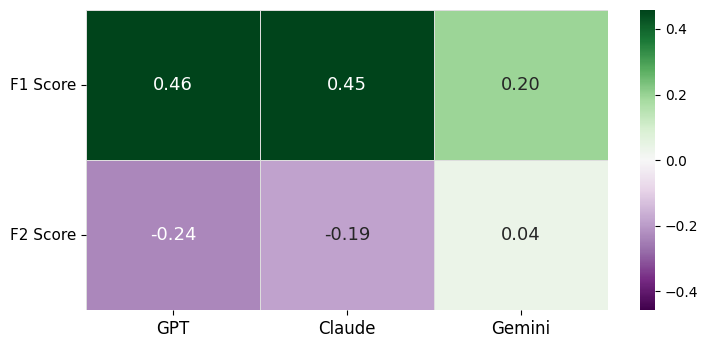

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

model_dfs = {
    'GPT':    df_retrieval_gpt,
    'Claude': df_retrieval_claude,
    'Gemini': df_retrieval_gemini,
}

events_filtered = events_order

all_neutral_diffs = {}

for model_name, df_raw in model_dfs.items():
    df_m = df_raw.copy()
    df_m['frame_name']     = df_m['query'].apply(lambda x: query_map.get(x, {}).get('frame'))
    df_m['query_type_new'] = df_m['query'].apply(lambda x: query_map.get(x, {}).get('query_type'))

    clean_df = df_m.rename(columns={
        'avg_frame_1_score': 'frame_1_score',
        'avg_frame_2_score': 'frame_2_score',
        'frame_name':        'query_frame',
        'query_type_new':    'query_type',
    }).copy()

    if 'metadata_type' not in clean_df.columns:
        clean_df['metadata_type'] = 'source+headline'

    clean_df.loc[clean_df['query_type'] == 'neutral', 'query_frame'] = 'neutral'

    neutral_diffs = compute_neutral_diffs(
        clean_df,
        annotations=df_articles,
        events_order=events_filtered,
        frame_cols=('frame_1_score', 'frame_2_score'),
        reorder_frames_by_lean=True,
        ci_method='bootstrap',
        n_boot=2000,
        ci=95,
        seed=0,
    )

    nd = neutral_diffs[neutral_diffs['metadata_type'] == 'source+headline'].copy()

    mean_diff_by_frame = nd.groupby('frame_key')['diff'].mean()
    all_neutral_diffs[model_name] = mean_diff_by_frame

matrix = pd.DataFrame(all_neutral_diffs).reindex(['frame_1', 'frame_2'])
matrix.index = ['F1 Score', 'F2 Score']

abs_max = matrix.abs().values.max()

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    matrix,
    ax=ax,
    cmap='PRGn',
    center=0,
    vmin=-abs_max,
    vmax=abs_max,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='#dddddd',
    annot_kws={'size': 13},
)

ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=11, rotation=0)
ax.collections[0].colorbar.ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## 6. Generation Results

Analyse how article-condition (frame_1_only / baseline / frame_2_only / both_interwoven) and query framing affect model generation frame scores.

### 6.1 Load generation data with response framing scores

In [43]:
df_generations = pd.read_csv('./data/df_generations_annotated.csv')

### 6.2 Split by model

In [16]:
df_generation_gpt = df_generations[df_generations['model'] == 'gpt-5.4']
df_generation_claude = df_generations[df_generations['model'] == 'claude-opus-4-6']
df_generation_gemini= df_generations[df_generations['model'] == 'gemini-3.1-pro-preview']

### 6.3 `events_swapped` normalisation

These are the events where we need to swap Frame 1 and Frame 2 to align with generally liberal / conservative perspectives

In [17]:
display(events_swapped)

{'alex_pretti',
 'charlie_kirk',
 'foreign_intelligence',
 'govt_shutdown',
 'kimmel',
 'maduro',
 'voting_rights_act'}

### 6.4 `models` dict

In [23]:
models = {
    'GPT':    df_generation_gpt,
    'Claude': df_generation_claude,
    'Gemini': df_generation_gemini,
}

### 6.5 Generation framing heatmap (article condition × query type)

Saved generation_framing_heatmap_multimodel.png


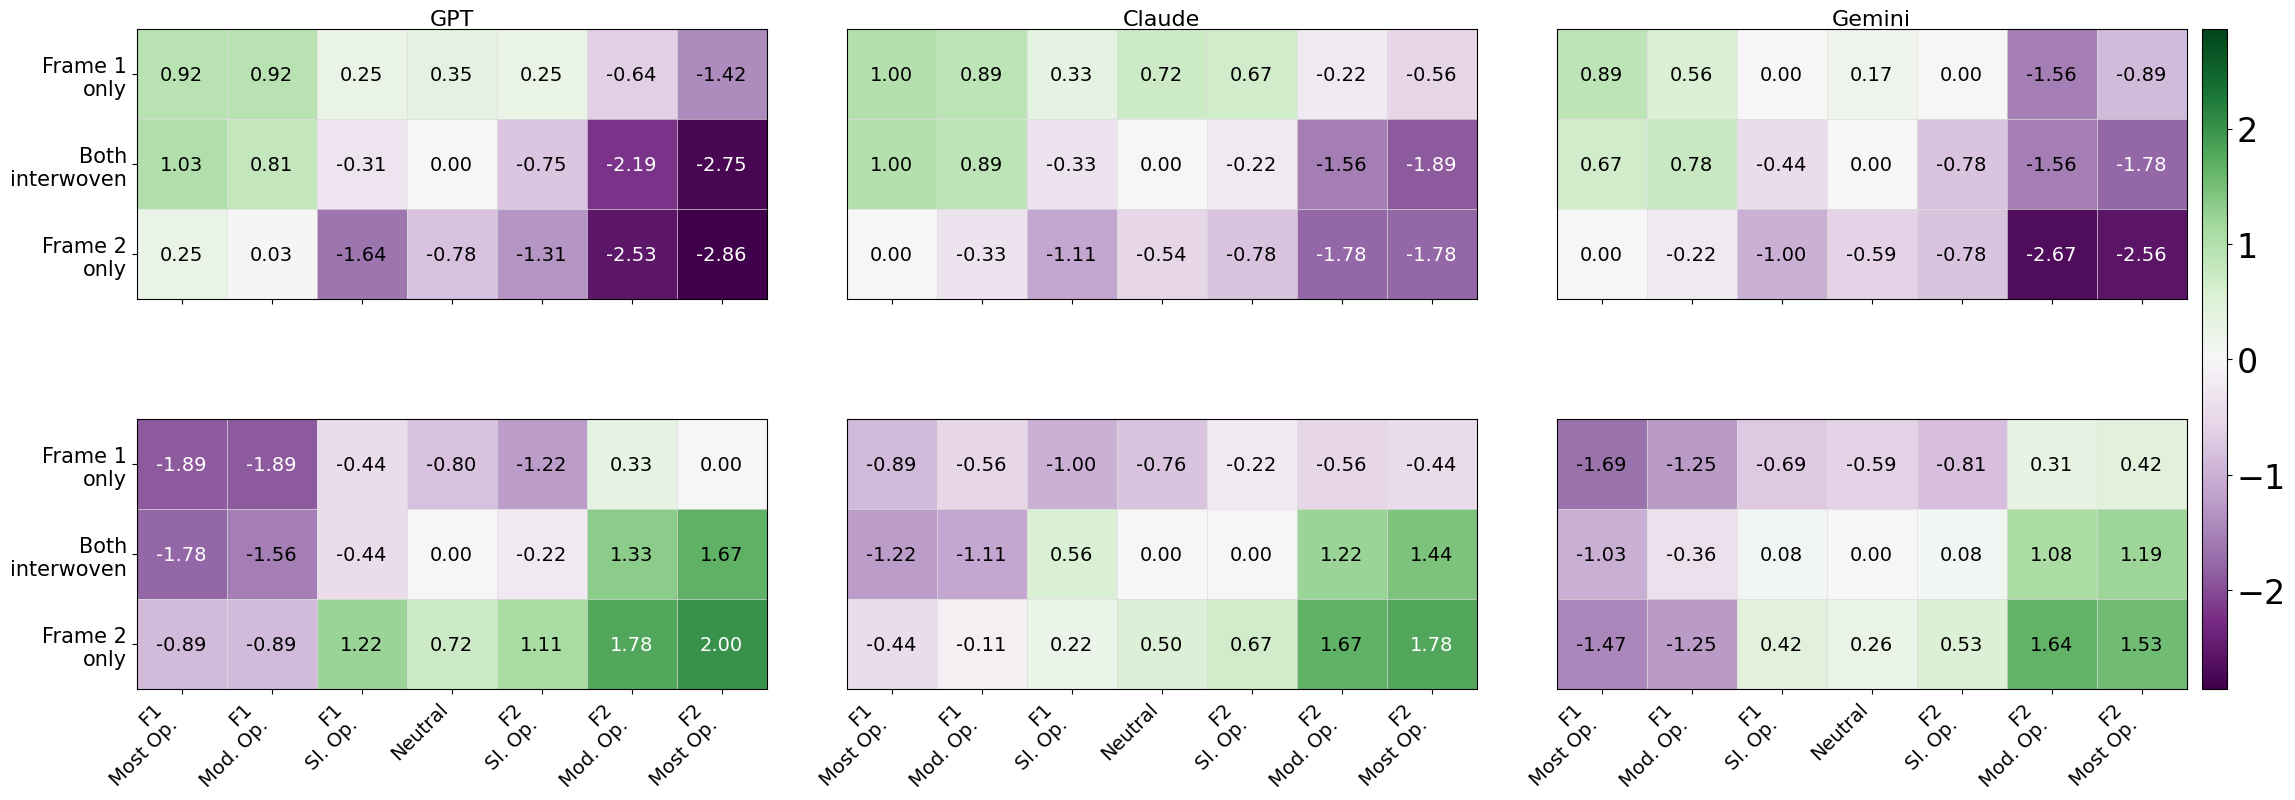

In [24]:
import matplotlib.pyplot as plt
import numpy as np

CMAP = 'PRGn'

col_order = [
    'frame_1_opinionated',
    'frame_1_leading',
    'frame_1_slightly_opinionated',
    'neutral_neutral',
    'frame_2_slightly_opinionated',
    'frame_2_leading',
    'frame_2_opinionated',
]
col_labels = [
    'F1\nMost Op.', 'F1\nMod. Op.', 'F1\nSl. Op.',
    'Neutral',
    'F2\nSl. Op.', 'F2\nMod. Op.', 'F2\nMost Op.',
]

row_order  = ['frame_1_only', 'baseline', 'frame_2_only']
row_labels = ['Frame 1\nonly', 'Both\ninterwoven', 'Frame 2\nonly']

n_rows_hm = len(row_order)
n_cols_hm = len(col_order)

def preprocess(df_raw):
    df = df_raw.copy()

    def map_article_condition(row):
        if row['condition'] == 'both_interwoven':
            return 'baseline'
        if row['event'] in events_swapped:
            return 'frame_2_only' if row['condition'] == 'frame_1_only' else 'frame_1_only'
        return row['condition']

    df['article_condition'] = df.apply(map_article_condition, axis=1)
    df['query_type']  = df['query'].map(lambda q: query_map.get(q, {}).get('query_type', 'neutral'))
    df['query_frame'] = df['query'].map(lambda q: query_map.get(q, {}).get('frame', 'neutral'))

    def frame_to_key(frame_name, event):
        if frame_name == 'neutral' or frame_name not in frame_alignment_map:
            return 'neutral'
        f1, f2 = event_to_frames[event]
        swapped = event in events_swapped
        if frame_name == f1: return 'frame_2' if swapped else 'frame_1'
        if frame_name == f2: return 'frame_1' if swapped else 'frame_2'
        return 'neutral'

    df['query_frame_key'] = df.apply(lambda r: frame_to_key(r['query_frame'], r['event']), axis=1)
    df['full_query_type'] = df['query_frame_key'] + '_' + df['query_type']

    baseline = (
        df[(df['article_condition'] == 'baseline') & (df['query_type'] == 'neutral')]
        .groupby('event')[['frame_1_score', 'frame_2_score']]
        .mean()
        .rename(columns={'frame_1_score': 'base_f1', 'frame_2_score': 'base_f2'})
    )
    df = df.drop(columns=['base_f1', 'base_f2'], errors='ignore').merge(baseline, on='event', how='left')

    df['change_f1'] = np.where(
        df['event'].isin(events_swapped),
        df['frame_2_score'] - df['base_f2'],
        df['frame_1_score'] - df['base_f1'],
    )
    df['change_f2'] = np.where(
        df['event'].isin(events_swapped),
        df['frame_1_score'] - df['base_f1'],
        df['frame_2_score'] - df['base_f2'],
    )
    return df

def build_matrix(hm_agg, score_col):
    mat = np.full((n_rows_hm, n_cols_hm), np.nan)
    for ri, art in enumerate(row_order):
        for ci, qt in enumerate(col_order):
            cell = hm_agg[
                (hm_agg['article_condition'] == art) &
                (hm_agg['full_query_type'] == qt)
            ]
            if not cell.empty:
                mat[ri, ci] = cell[score_col].values[0]
    return mat

matrices = {}
all_vals = []

for name, df_raw in models.items():
    df_m = preprocess(df_raw)
    hm_agg = (
        df_m.groupby(['article_condition', 'full_query_type'])[['change_f1', 'change_f2']]
        .mean()
        .reset_index()
    )
    mat_f1 = build_matrix(hm_agg, 'change_f1')
    mat_f2 = build_matrix(hm_agg, 'change_f2')
    matrices[name] = [mat_f1, mat_f2]
    all_vals.extend([mat_f1[~np.isnan(mat_f1)], mat_f2[~np.isnan(mat_f2)]])

vmax_s = np.max(np.abs(np.concatenate(all_vals)))
vmin_s = -vmax_s

def draw_heatmap(ax, mat, title, show_yticks, vmin, vmax, fontsize_annot=9, fontsize_tick=9):
    im = ax.imshow(mat, aspect='equal', cmap=CMAP, vmin=vmin, vmax=vmax)
    for x in np.arange(-0.5, n_cols_hm, 1):
        ax.axvline(x, color='#dddddd', linewidth=0.5)
    for y in np.arange(-0.5, n_rows_hm, 1):
        ax.axhline(y, color='#dddddd', linewidth=0.5)
    for ri in range(n_rows_hm):
        for ci in range(n_cols_hm):
            val = mat[ri, ci]
            if not np.isnan(val):
                ax.text(ci, ri, f'{val:.2f}', ha='center', va='center',
                        fontsize=fontsize_annot,
                        color='white' if abs(val) > vmax * 0.6 else 'black')
    ax.set_xticks(range(n_cols_hm))
    ax.set_xticklabels(col_labels, fontsize=fontsize_tick, rotation=45, ha='right')
    ax.set_title(title, fontsize=fontsize_tick + 2, pad=3)
    if show_yticks:
        ax.set_yticks(range(n_rows_hm))
        ax.set_yticklabels(row_labels, fontsize=fontsize_tick + 1)
    else:
        ax.set_yticks([])
    return im

model_names  = list(models.keys())
frame_labels = ['Frame 1 Alignment Score', 'Frame 2 Alignment Score']
frame_keys   = ['change_f1', 'change_f2']

s_cell   = 0.9
s_hm_w   = n_cols_hm * s_cell
s_hm_h   = n_rows_hm * s_cell
s_gap_x  = 0.8
s_gap_y  = 1.2
s_mar_l  = 4.5
s_mar_r  = 1.4
s_mar_t  = 1.2
s_mar_b  = 1.5
s_cbar_w = 0.25
s_row_label_w = 2.2

n_frame_rows = 2
n_model_cols = len(model_names)

fig_s_w = s_mar_l + n_model_cols * s_hm_w + (n_model_cols - 1) * s_gap_x + s_cbar_w + s_mar_r + 4.0
fig_s_h = s_mar_t + n_frame_rows * s_hm_h + (n_frame_rows - 1) * s_gap_y + s_mar_b

fig_s = plt.figure(figsize=(fig_s_w, fig_s_h))

def to_fig_s(x_in, y_in, w_in, h_in):
    return [x_in / fig_s_w, y_in / fig_s_h, w_in / fig_s_w, h_in / fig_s_h]

im_s = None

for fi, (fkey, flabel) in enumerate(zip(frame_keys, frame_labels)):
    y0 = fig_s_h - s_mar_t - (fi + 1) * s_hm_h - fi * s_gap_y
    is_top_row    = (fi == 0)
    is_bottom_row = (fi == n_frame_rows - 1)

    for mi, name in enumerate(model_names):
        x0 = s_mar_l + mi * (s_hm_w + s_gap_x)
        is_left_col = (mi == 0)

        mat = matrices[name][fi]
        ax  = fig_s.add_axes(to_fig_s(x0, y0, s_hm_w, s_hm_h))

        im_s = draw_heatmap(
            ax, mat,
            title=name if is_top_row else '',
            show_yticks=is_left_col,
            vmin=vmin_s, vmax=vmax_s,
            fontsize_annot=14, fontsize_tick=14,
        )

        if not is_bottom_row:
            ax.set_xticklabels([])


total_hm_height = n_frame_rows * s_hm_h + (n_frame_rows - 1) * s_gap_y
cbar_y0 = fig_s_h - s_mar_t - total_hm_height
cbar_x0 = s_mar_l + n_model_cols * s_hm_w + (n_model_cols - 1) * s_gap_x + 0.15

cbar_ax_s = fig_s.add_axes(to_fig_s(cbar_x0, cbar_y0, s_cbar_w, total_hm_height))
fig_s.colorbar(im_s, cax=cbar_ax_s, label='')

plt.savefig('generation_framing_heatmap_multimodel.png', dpi=150, bbox_inches='tight')
print('Saved generation_framing_heatmap_multimodel.png')

### 6.6 Examine generation frame-score difference under neutral queries

In [29]:
results_f1 = {}
results_f2 = {}

for name, df_raw in models.items():
    df_m = preprocess(df_raw)

    df_m['conceptual_f1_score'] = np.where(
        df_m['event'].isin(events_swapped),
        df_m['frame_2_score'],
        df_m['frame_1_score']
    )
    df_m['conceptual_f2_score'] = np.where(
        df_m['event'].isin(events_swapped),
        df_m['frame_1_score'],
        df_m['frame_2_score']
    )

    # Filter to neutral queries only
    df_neutral = df_m[df_m['full_query_type'] == 'neutral_neutral']

    summary = (
        df_neutral
        .groupby('article_condition')[['conceptual_f1_score', 'conceptual_f2_score']]
        .mean()
        .reindex(row_order)
        .rename(index=dict(zip(row_order, row_labels)))
    )

    results_f1[name] = summary['conceptual_f1_score']
    results_f2[name] = summary['conceptual_f2_score']

df_f1 = pd.DataFrame(results_f1).round(4)
df_f2 = pd.DataFrame(results_f2).round(4)
df_diff = (df_f1 - df_f2).round(4)

# This data is from the input article set used for generation
input_data = pd.Series({
    'frame_1_only':     1.220000 - (-1.280000),
    'both_interwoven': -0.203333 - 0.123333,
    'frame_2_only':    -1.626667 - 1.526667,
}, name='Input Data')

df_diff['Input Data'] = input_data.round(4)


print("=== Conceptual Frame 1 Score ===")
print(df_f1)

print("\n=== Conceptual Frame 2 Score ===")
print(df_f2)

print("\n=== F1 - F2 Difference ===")
print(df_diff)

=== Conceptual Frame 1 Score ===
                      GPT  Claude  Gemini
article_condition                        
Frame 1\nonly      0.9348  1.1522  0.7174
Both\ninterwoven   0.5870  0.4348  0.5435
Frame 2\nonly     -0.1957 -0.1087 -0.0435

=== Conceptual Frame 2 Score ===
                      GPT  Claude  Gemini
article_condition                        
Frame 1\nonly     -0.9565 -0.7391 -0.1957
Both\ninterwoven  -0.1522  0.0217  0.3913
Frame 2\nonly      0.5652  0.5217  0.6522

=== F1 - F2 Difference ===
                      GPT  Claude  Gemini  Input Data
article_condition                                    
Frame 1\nonly      1.8913  1.8913  0.9131         NaN
Both\ninterwoven   0.7392  0.4131  0.1522         NaN
Frame 2\nonly     -0.7609 -0.6304 -0.6957         NaN


### 6.7 Article-condition Heatmaps, Neutral Query

Here, we look at the frame alignment scores for generation under neutral queries across article conditions, comparing to the frame alignment scores of the input articles. In the paper, we show Claude, GPT, and Gemini for this figure, but in this code, we arrange it to be GPT, Claude, Gemini to be consistent with other figures.

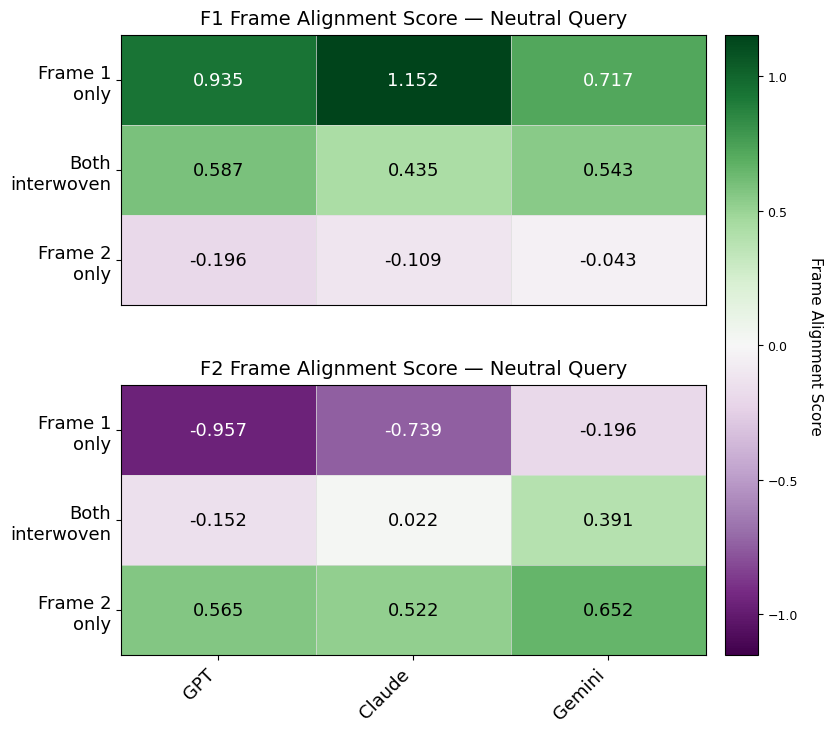

In [41]:
#This chart graphs the raw neutral query values 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

model_dfs = models

CMAP = 'PRGn'

n_rows_hm = len(row_order)
model_names = list(model_dfs.keys())
n_cols_hm = len(model_names)

mat_f1 = np.full((n_rows_hm, n_cols_hm), np.nan)
mat_f2 = np.full((n_rows_hm, n_cols_hm), np.nan)

for mi, (model_name, df_raw) in enumerate(model_dfs.items()):

    df_m = preprocess(df_raw)

    df_m['conceptual_f1_score'] = np.where(
        df_m['event'].isin(events_swapped),
        df_m['frame_2_score'],
        df_m['frame_1_score']
    )

    df_m['conceptual_f2_score'] = np.where(
        df_m['event'].isin(events_swapped),
        df_m['frame_1_score'],
        df_m['frame_2_score']
    )

    df_neutral = df_m[
        df_m['full_query_type'] == 'neutral_neutral'
    ]

    for ri, art_cond in enumerate(row_order):

        subset = df_neutral[
            df_neutral['article_condition'] == art_cond
        ]

        if subset.empty:
            continue

        mat_f1[ri, mi] = subset['conceptual_f1_score'].mean()
        mat_f2[ri, mi] = subset['conceptual_f2_score'].mean()

all_vals = np.concatenate([
    mat_f1[~np.isnan(mat_f1)],
    mat_f2[~np.isnan(mat_f2)]
])

abs_max = np.max(np.abs(all_vals))

s_cell = 1.5

s_hm_w = n_cols_hm * s_cell
s_hm_h = n_rows_hm * 0.9

s_gap_y = 0.8

s_mar_l = 3.5
s_mar_r = 1.2
s_mar_t = 0.8
s_mar_b = 1.2

s_cbar_w = 0.25

fig_w = s_mar_l + s_hm_w + s_cbar_w + s_mar_r + 2.0
fig_h = s_mar_t + 2 * s_hm_h + s_gap_y + s_mar_b

fig = plt.figure(figsize=(fig_w * 1.3, fig_h))

def to_fig(x, y, w, h):
    return [x / fig_w, y / fig_h, w / fig_w, h / fig_h]

y0_f1 = fig_h - s_mar_t - s_hm_h

ax_f1 = fig.add_axes(
    to_fig(
        s_mar_l,
        y0_f1,
        s_hm_w,
        s_hm_h
    )
)

im = draw_heatmap_neutral(
    ax_f1, mat_f1, 'F1 Frame Alignment Score — Neutral Query',
    vmin=-abs_max, vmax=abs_max, show_xticks=False,
    row_labels=row_labels, col_labels=model_names
)

y0_f2 = fig_h - s_mar_t - 2 * s_hm_h - s_gap_y

ax_f2 = fig.add_axes(
    to_fig(
        s_mar_l,
        y0_f2,
        s_hm_w,
        s_hm_h
    )
)


im = draw_heatmap_neutral(
    ax_f2, mat_f2, 'F2 Frame Alignment Score — Neutral Query',
    vmin=-abs_max, vmax=abs_max, show_xticks=True,
    row_labels=row_labels, col_labels=model_names
)


total_h = 2 * s_hm_h + s_gap_y

cbar_x0 = s_mar_l + s_hm_w + 0.15

cbar_ax = fig.add_axes(
    to_fig(
        cbar_x0,
        y0_f2,
        s_cbar_w,
        total_h
    )
)

sm = plt.cm.ScalarMappable(
    cmap=CMAP,
    norm=plt.Normalize(
        vmin=-abs_max,
        vmax=abs_max
    )
)

sm.set_array([])

cb = fig.colorbar(
    sm,
    cax=cbar_ax
)

cb.set_label(
    'Frame Alignment Score',
    fontsize=11,
    rotation=270,
    labelpad=18
)

cbar_ax.tick_params(labelsize=9)

plt.savefig(
    'generation_neutral_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

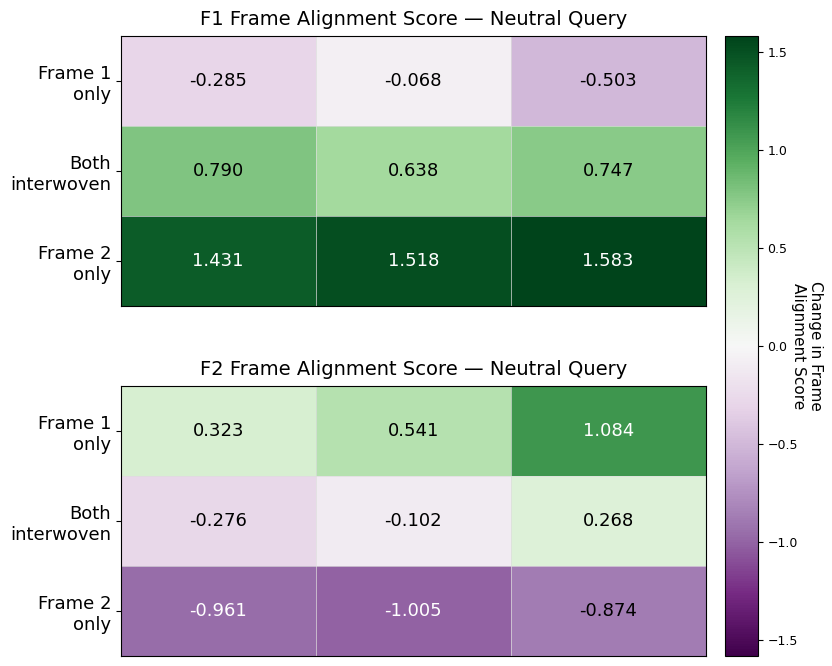

In [42]:
#This chart graphs the difference between the input article scores and the neutral query scores 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

model_dfs = models 

CMAP = 'PRGn'

# This data is from the input articles used for generation
input_base_f1 = {
    'frame_1_only':     1.220000,
    'baseline':        -0.203333,
    'frame_2_only':    -1.626667,
}

input_base_f2 = {
    'frame_1_only':    -1.280000,
    'baseline':         0.123333,
    'frame_2_only':     1.526667,
}

n_rows_hm = len(row_order)
model_names = list(model_dfs.keys())
n_cols_hm = len(model_names)

# Build F1 and F2 matrices
mat_f1 = np.full((n_rows_hm, n_cols_hm), np.nan)
mat_f2 = np.full((n_rows_hm, n_cols_hm), np.nan)

for mi, (model_name, df_raw) in enumerate(model_dfs.items()):

    df_m = preprocess(df_raw)

    df_m['conceptual_f1_score'] = np.where(
        df_m['event'].isin(events_swapped),
        df_m['frame_2_score'],
        df_m['frame_1_score']
    )

    df_m['conceptual_f2_score'] = np.where(
        df_m['event'].isin(events_swapped),
        df_m['frame_1_score'],
        df_m['frame_2_score']
    )

    df_neutral = df_m[df_m['full_query_type'] == 'neutral_neutral']

    for ri, art_cond in enumerate(row_order):

        subset = df_neutral[
            df_neutral['article_condition'] == art_cond
        ]

        if subset.empty:
            continue

        mat_f1[ri, mi] = (
            subset['conceptual_f1_score'].mean()
            - input_base_f1[art_cond]
        )

        mat_f2[ri, mi] = (
            subset['conceptual_f2_score'].mean()
            - input_base_f2[art_cond]
        )

all_vals = np.concatenate([
    mat_f1[~np.isnan(mat_f1)],
    mat_f2[~np.isnan(mat_f2)]
])

abs_max = np.max(np.abs(all_vals))

s_cell   = 1.5
s_hm_w   = n_cols_hm * s_cell
s_hm_h   = n_rows_hm * 0.9

s_gap_y  = 0.8

s_mar_l  = 3.5
s_mar_r  = 1.2
s_mar_t  = 0.8
s_mar_b  = 1.2

s_cbar_w = 0.25

fig_w = s_mar_l + s_hm_w + s_cbar_w + s_mar_r + 2.0
fig_h = s_mar_t + 2 * s_hm_h + s_gap_y + s_mar_b

fig = plt.figure(figsize=(fig_w * 1.3, fig_h))

def to_fig(x, y, w, h):
    return [x / fig_w, y / fig_h, w / fig_w, h / fig_h]

y0_f1 = fig_h - s_mar_t - s_hm_h

ax_f1 = fig.add_axes(
    to_fig(
        s_mar_l,
        y0_f1,
        s_hm_w,
        s_hm_h
    )
)


im = draw_heatmap_neutral(
    ax_f1, mat_f1, 'F1 Frame Alignment Score — Neutral Query',
    vmin=-abs_max, vmax=abs_max, show_xticks=False,
    row_labels=row_labels, col_labels=model_names
)

y0_f2 = fig_h - s_mar_t - 2 * s_hm_h - s_gap_y

ax_f2 = fig.add_axes(
    to_fig(
        s_mar_l,
        y0_f2,
        s_hm_w,
        s_hm_h
    )
)

im = draw_heatmap_neutral(
    ax_f2, mat_f2, 'F2 Frame Alignment Score — Neutral Query',
    vmin=-abs_max, vmax=abs_max, show_xticks=False,
    row_labels=row_labels, col_labels=model_names
)

total_h = 2 * s_hm_h + s_gap_y

cbar_x0 = s_mar_l + s_hm_w + 0.15

cbar_ax = fig.add_axes(
    to_fig(
        cbar_x0,
        y0_f2,
        s_cbar_w,
        total_h
    )
)

sm = plt.cm.ScalarMappable(
    cmap=CMAP,
    norm=plt.Normalize(
        vmin=-abs_max,
        vmax=abs_max
    )
)

sm.set_array([])

cb = fig.colorbar(
    sm,
    cax=cbar_ax
)

cb.set_label(
    'Change in Frame\nAlignment Score',
    fontsize=11,
    rotation=270,
    labelpad=18
)

cbar_ax.tick_params(labelsize=9)

plt.savefig(
    'generation_neutral_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()